In [11]:
import os
import math
import pandas as pd
import sqlite3

pd.set_option('future.no_silent_downcasting', True)

_DB_PATH = os.path.join(os.getcwd(), "../../data/ai_audit_db.sqlite")


# ─────────────────────────────────────────────────────────────────────────────
# Database Helper
# ─────────────────────────────────────────────────────────────────────────────
def get_data_from_db(query: str) -> pd.DataFrame:
    """Execute a SQL query and return results as a DataFrame."""
    try:
        conn = sqlite3.connect(_DB_PATH, timeout=30)
        df = pd.read_sql_query(query, conn)
        conn.close()
        return df
    except Exception as e:
        print(f"❌ Error reading from database: {e}")
        return pd.DataFrame()


# ─────────────────────────────────────────────────────────────────────────────
# 1. Revenue Features
# ─────────────────────────────────────────────────────────────────────────────
def Revenue_Features() -> pd.DataFrame:
    """Monthly revenue with lags, rolling stats, and calendar encodings."""
    revenue_by_month = get_data_from_db("""
        SELECT SUM(total_amount) AS total,
               strftime('%Y-%m', invoice_date) AS month
        FROM invoices
        WHERE type = 'out_invoice'
        GROUP BY month
    """)

    if revenue_by_month.empty:
        raise ValueError("Revenue_Features: No invoice data found.")

    revenue_by_month['month'] = pd.to_datetime(revenue_by_month['month'])
    revenue_by_month = revenue_by_month.sort_values('month').reset_index(drop=True)

    # Lags & rolling stats (Month-over-Month only; YoY removed due to short history)
    revenue_by_month['revenue_lag_1']      = revenue_by_month['total'].shift(1)
    revenue_by_month['revenue_lag_3']      = revenue_by_month['total'].shift(3)
    revenue_by_month['revenue_lag_2']      = revenue_by_month['total'].shift(2)
    revenue_by_month['revenue_growth_mom'] = revenue_by_month['total'].pct_change(1)
    revenue_by_month['revenue_ma_3']       = revenue_by_month['total'].rolling(3).mean()
    revenue_by_month['revenue_ma_6']       = revenue_by_month['total'].rolling(6).mean()
    revenue_by_month['revenue_std_3']      = revenue_by_month['total'].rolling(3).std()

    # Calendar features
    revenue_by_month['month_num']   = revenue_by_month['month'].dt.month
    revenue_by_month['quarter']     = revenue_by_month['month'].dt.quarter
    revenue_by_month['month_sin']   = (revenue_by_month['month_num'] * 2 * math.pi / 12).apply(math.sin)
    revenue_by_month['month_cos']   = (revenue_by_month['month_num'] * 2 * math.pi / 12).apply(math.cos)
    revenue_by_month['is_year_end'] = revenue_by_month['month_num'].isin([11, 12]).astype(int)

    revenue_by_month['month'] = revenue_by_month['month'].dt.strftime('%Y-%m')

    print("✅ Revenue Features:")
    print(revenue_by_month[['month', 'total', 'revenue_growth_mom', 'revenue_ma_3', 'revenue_std_3']].tail())
    return revenue_by_month


# ─────────────────────────────────────────────────────────────────────────────
# 2. COGS & Operating Expenses
# ─────────────────────────────────────────────────────────────────────────────
def cogs_expenses_features(features_df: pd.DataFrame = None) -> pd.DataFrame:
    """
    Add:
      - COGS calculated from sold items (quantity * product.cost)
      - Operating expenses from journal entries (account type = 'expense')
    """
    if features_df is None:
        features_df = Revenue_Features()

    # COGS = cost of goods actually SOLD (matched to revenue month)
    monthly_cogs = get_data_from_db("""
        SELECT strftime('%Y-%m', inv.invoice_date) AS month,
               SUM(il.quantity * p.cost) AS total_cogs
        FROM invoice_lines il
        JOIN invoices inv ON il.invoice_id = inv.id
        JOIN products p   ON il.product_id = p.id
        WHERE inv.type = 'out_invoice'
        GROUP BY month
    """)

    if monthly_cogs.empty:
        print("⚠️  Warning: No COGS data found. Check products.cost values.")
        monthly_cogs = pd.DataFrame(columns=['month', 'total_cogs'])

    # Operating Expenses (excluding COGS – only 'expense' accounts)
    monthly_expenses = get_data_from_db("""
        SELECT strftime('%Y-%m', je.entry_date) AS month,
               SUM(jl.debit) - SUM(jl.credit) AS total_expenses
        FROM journal_lines jl
        JOIN journal_entries je ON jl.journal_entry_id = je.id
        JOIN accounts a ON jl.account_id = a.id
        WHERE a.type = 'expense'
        GROUP BY month
    """)

    if monthly_expenses.empty:
        print("⚠️  Warning: No expense journal entries found.")
        monthly_expenses = pd.DataFrame(columns=['month', 'total_expenses'])

    # Merge into feature set
    features_df = (
        features_df.rename(columns={'total': 'monthly_revenue'})
        .merge(monthly_cogs, on='month', how='left')
        .merge(monthly_expenses, on='month', how='left')
    )

    # Check for missing COGS (possible data integrity issue)
    if features_df['total_cogs'].isna().any():
        missing_months = features_df.loc[features_df['total_cogs'].isna(), 'month'].tolist()
        print(f"⚠️  Warning: COGS missing for months: {missing_months}. Filling with 0.")
        features_df['total_cogs'] = features_df['total_cogs'].fillna(0)
    else:
        features_df['total_cogs'] = features_df['total_cogs'].fillna(0).infer_objects(copy=False)

    features_df['total_expenses'] = features_df['total_expenses'].fillna(0).infer_objects(copy=False)

    # Ratios
    features_df['cogs_to_revenue_ratio'] = (
        features_df['total_cogs'] / features_df['monthly_revenue'].replace(0, pd.NA)
    )
    features_df['expense_ratio'] = (
        features_df['total_expenses'] / features_df['monthly_revenue'].replace(0, pd.NA)
    )

    print("\n✅ COGS & Expenses Features:")
    print(features_df[['month', 'monthly_revenue', 'total_cogs', 'cogs_to_revenue_ratio', 'expense_ratio']].tail())
    return features_df


# ─────────────────────────────────────────────────────────────────────────────
# 3. Unit Economics
# ─────────────────────────────────────────────────────────────────────────────
def Unit_Economics_Features(features_df: pd.DataFrame = None) -> pd.DataFrame:
    """Gross margin, weighted average margin, and margin volatility."""
    if features_df is None:
        features_df = cogs_expenses_features()

    # Gross margin from total revenue and COGS
    features_df['gross_margin'] = (
        (features_df['monthly_revenue'] - features_df['total_cogs'])
        / features_df['monthly_revenue'].replace(0, pd.NA)
    )

    # Weighted average margin per invoice line (for product‑mix insight)
    monthly_margin = get_data_from_db("""
        SELECT strftime('%Y-%m', inv.invoice_date) AS month,
               SUM(il.quantity * (il.unit_price - p.cost))
               / NULLIF(SUM(il.quantity * il.unit_price), 0) AS weighted_avg_margin
        FROM invoice_lines il
        JOIN invoices inv ON il.invoice_id = inv.id
        JOIN products p   ON il.product_id = p.id
        WHERE inv.type = 'out_invoice'
        GROUP BY month
    """)

    if not monthly_margin.empty:
        features_df = features_df.merge(monthly_margin, on='month', how='left')
    else:
        features_df['weighted_avg_margin'] = pd.NA

    print("\n✅ Unit Economics Features:")
    print(features_df[['month', 'gross_margin', 'weighted_avg_margin']].tail())
    return features_df


# ─────────────────────────────────────────────────────────────────────────────
# 4. Cash Flow & Collection Metrics
# ─────────────────────────────────────────────────────────────────────────────
def Cash_Flow_Features(features_df: pd.DataFrame = None) -> pd.DataFrame:
    """DSO, overdue ratio, collection gap, and payment method mix."""
    if features_df is None:
        features_df = Unit_Economics_Features()

    # Days Sales Outstanding (DSO)
    dso_df = get_data_from_db("""
        SELECT strftime('%Y-%m', i.invoice_date) AS month,
               AVG(julianday(p.payment_date) - julianday(i.invoice_date)) AS dso_days
        FROM invoices i
        JOIN payments p ON i.id = p.invoice_id
        WHERE i.type = 'out_invoice'
        GROUP BY month
    """)

    # Overdue amount and ratio
    overdue_df = get_data_from_db("""
        SELECT strftime('%Y-%m', i.invoice_date) AS month,
               SUM(CASE
                    WHEN p.payment_date IS NULL
                      OR julianday(p.payment_date) > julianday(i.due_date)
                    THEN i.total_amount ELSE 0
               END) AS overdue_amount,
               SUM(i.total_amount) AS total_invoiced
        FROM invoices i
        LEFT JOIN payments p ON i.id = p.invoice_id
        WHERE i.type = 'out_invoice'
        GROUP BY month
    """)

    if not overdue_df.empty:
        overdue_df['overdue_ratio'] = (
            overdue_df['overdue_amount'] / overdue_df['total_invoiced'].replace(0, pd.NA)
        )

    # Billed vs Collected in same month
    billed_collected_df = get_data_from_db("""
        SELECT month,
               SUM(billed_this_month)    AS billed_this_month,
               SUM(collected_this_month) AS collected_this_month
        FROM (
            SELECT strftime('%Y-%m', invoice_date) AS month,
                   total_amount AS billed_this_month,
                   0            AS collected_this_month
            FROM invoices WHERE type = 'out_invoice'
            UNION ALL
            SELECT strftime('%Y-%m', p.payment_date) AS month,
                   0         AS billed_this_month,
                   p.amount  AS collected_this_month
            FROM payments p
            JOIN invoices i ON p.invoice_id = i.id
            WHERE i.type = 'out_invoice'
        )
        WHERE month IS NOT NULL
        GROUP BY month
    """)

    # Payment method percentages
    payment_method_df = get_data_from_db("""
        SELECT strftime('%Y-%m', p.payment_date) AS month,
               SUM(CASE WHEN LOWER(p.payment_method) LIKE '%cash%'
                        THEN p.amount ELSE 0 END)
               / NULLIF(SUM(p.amount), 0) AS pct_paid_cash,
               SUM(CASE WHEN LOWER(p.payment_method) LIKE '%credit%'
                          OR LOWER(p.payment_method) LIKE '%card%'
                        THEN p.amount ELSE 0 END)
               / NULLIF(SUM(p.amount), 0) AS pct_paid_credit
        FROM payments p
        JOIN invoices i ON p.invoice_id = i.id
        WHERE i.type = 'out_invoice'
        GROUP BY month
    """)

    # Merge all cash flow features (NO lags yet)
    features_df = features_df.merge(dso_df, on='month', how='left')

    if not overdue_df.empty:
        features_df = features_df.merge(overdue_df[['month', 'overdue_amount', 'overdue_ratio']],
                                        on='month', how='left')

    if not billed_collected_df.empty:
        features_df = features_df.merge(billed_collected_df, on='month', how='left')
        # Compute collection gap and its lag AFTER merging (ensuring continuous timeline)
        features_df['collection_gap'] = (
            features_df['billed_this_month'] - features_df['collected_this_month']
        )
        features_df['collection_gap_lag_1'] = features_df['collection_gap'].shift(1)

    if not payment_method_df.empty:
        features_df = features_df.merge(payment_method_df, on='month', how='left')

    print("\n✅ Cash Flow Features:")
    cols_to_print = [c for c in ['month', 'dso_days', 'overdue_ratio', 'collection_gap', 'pct_paid_cash'] if c in features_df.columns]
    print(features_df[cols_to_print].tail())
    return features_df


# ─────────────────────────────────────────────────────────────────────────────
# 5. Volume, Customer Concentration & Purchase Order Activity
# ─────────────────────────────────────────────────────────────────────────────
def Volume_Activity_Features(features_df: pd.DataFrame = None) -> pd.DataFrame:
    """Invoice volume, customer concentration, and purchase order trends."""
    if features_df is None:
        features_df = Cash_Flow_Features()

    # Transaction volume – FIXED: use customer_id for sales invoices
    tx_volume_df = get_data_from_db("""
        SELECT strftime('%Y-%m', invoice_date) AS month,
               COUNT(*)                        AS invoice_count,
               AVG(total_amount)               AS avg_invoice_value,
               COUNT(DISTINCT customer_id)     AS unique_customers
        FROM invoices
        WHERE type = 'out_invoice'
        GROUP BY month
    """)

    # Customer concentration (top 1 and top 3 customers share of revenue)
    concentration_df = get_data_from_db("""
        WITH MonthlyRevenue AS (
            SELECT strftime('%Y-%m', invoice_date) AS month,
                   customer_id,
                   SUM(total_amount) AS customer_revenue
            FROM invoices
            WHERE type = 'out_invoice'
            GROUP BY month, customer_id
        ),
        TotalPerMonth AS (
            SELECT month, SUM(customer_revenue) AS total_revenue
            FROM MonthlyRevenue
            GROUP BY month
        ),
        RankedRevenue AS (
            SELECT m.month,
                   m.customer_revenue,
                   t.total_revenue,
                   ROW_NUMBER() OVER (PARTITION BY m.month ORDER BY m.customer_revenue DESC) AS rank
            FROM MonthlyRevenue m
            JOIN TotalPerMonth t ON m.month = t.month
        )
        SELECT month,
               SUM(CASE WHEN rank = 1  THEN customer_revenue ELSE 0 END)
               / NULLIF(MAX(total_revenue), 0) AS top1_customer_pct,
               SUM(CASE WHEN rank <= 3 THEN customer_revenue ELSE 0 END)
               / NULLIF(MAX(total_revenue), 0) AS top3_customers_pct
        FROM RankedRevenue
        GROUP BY month
    """)

    # Purchase order activity (for inventory planning, NOT for COGS)
    po_df = get_data_from_db("""
        SELECT strftime('%Y-%m', order_date) AS month,
               COUNT(*)           AS po_count,
               SUM(total_amount)  AS po_total_value
        FROM purchase_orders
        WHERE status = 'done'
        GROUP BY month
    """)

    # Merge all volume/activity data (NO lags yet)
    features_df = features_df.merge(tx_volume_df, on='month', how='left')
    features_df = features_df.merge(concentration_df, on='month', how='left')
    features_df = features_df.merge(po_df, on='month', how='left')

    # Compute PO lag AFTER merging (ensures continuous timeline)
    if not po_df.empty:
        features_df['po_lag_1'] = features_df['po_total_value'].shift(1)

    # Lags for unit economics and cash flow (now on the full DataFrame)
    features_df['gross_margin_lag_1'] = features_df['gross_margin'].shift(1)
    features_df['gross_margin_ma_3']  = features_df['gross_margin'].rolling(3).mean()
    features_df['margin_delta_mom']   = features_df['gross_margin'].diff(1)

    features_df['cogs_lag_1']      = features_df['total_cogs'].shift(1)
    features_df['cogs_lag_3']      = features_df['total_cogs'].shift(3)
    features_df['expense_lag_1']   = features_df['total_expenses'].shift(1)
    
    # Safely compute pct_change to avoid ZeroDivisionError
    features_df['cogs_growth_mom'] = (
        features_df['total_cogs'] / features_df['total_cogs'].shift(1).replace(0, pd.NA) 
    ) - 1

    # Net profit (Revenue - COGS - Operating Expenses)
    features_df['net_profit'] = (
        features_df['monthly_revenue']
        - features_df['total_cogs']
        - features_df['total_expenses']
    )

    # Target: next month's net profit (shift backwards)
    features_df['target_profit'] = features_df['net_profit'].shift(-1)
    features_df = features_df.dropna(subset=['target_profit'])

    print("\n✅ Volume & Activity Features:")
    print(features_df[['month', 'invoice_count', 'unique_customers', 'top1_customer_pct', 'po_total_value']].tail())
    return features_df


# ─────────────────────────────────────────────────────────────────────────────
# Orchestrator
# ─────────────────────────────────────────────────────────────────────────────
def build_feature_pipeline() -> pd.DataFrame:
    """Run the complete feature pipeline and return the final DataFrame."""
    print("=" * 60)
    print("🚀 Running feature engineering pipeline...")
    print("=" * 60)

    revenue_df = Revenue_Features()
    features_df = cogs_expenses_features(revenue_df)
    features_df = Unit_Economics_Features(features_df)
    features_df = Cash_Flow_Features(features_df)
    features_df = Volume_Activity_Features(features_df)

    print("\n" + "=" * 60)
    print(f"✅ Pipeline complete. Shape: {features_df.shape}")
    print(f"📊 Columns ({len(features_df.columns)}): {list(features_df.columns)}")
    print("=" * 60)

    # Ensure numeric types (some empty merges leave object columns)
    for col in features_df.columns:
        if col != 'month':
            features_df[col] = pd.to_numeric(features_df[col], errors='coerce')

    return features_df




In [18]:
import os
import math
import sqlite3
import pandas as pd

pd.set_option('future.no_silent_downcasting', True)

_DB_PATH = os.path.join(os.getcwd(), "../../data/ai_audit_db.sqlite")

# ─────────────────────────────────────────────────────────────────────────────
# Database Helper
# ─────────────────────────────────────────────────────────────────────────────
def get_data_from_db(query: str) -> pd.DataFrame:
    try:
        conn = sqlite3.connect(_DB_PATH, timeout=30)
        df = pd.read_sql_query(query, conn)
        conn.close()
        return df
    except Exception as e:
        print(f"❌ DB error: {e}")
        return pd.DataFrame()


# ─────────────────────────────────────────────────────────────────────────────
# 1. Revenue Features
# ─────────────────────────────────────────────────────────────────────────────
def Revenue_Features() -> pd.DataFrame:
    """Monthly revenue with lags, rolling stats, and calendar encodings."""

    revenue_by_month = get_data_from_db("""
        SELECT SUM(total_amount) AS total,
               strftime('%Y-%m', invoice_date) AS month
        FROM invoices
        WHERE type = 'out_invoice'
        GROUP BY month
        ORDER BY month
    """)

    if revenue_by_month.empty:
        raise ValueError("Revenue_Features: No invoice data found.")

    revenue_by_month['month'] = pd.to_datetime(revenue_by_month['month'])
    revenue_by_month = revenue_by_month.sort_values('month').reset_index(drop=True)

    revenue_by_month['revenue_lag_1']      = revenue_by_month['total'].shift(1)
    revenue_by_month['revenue_lag_2']      = revenue_by_month['total'].shift(2)
    revenue_by_month['revenue_lag_3']      = revenue_by_month['total'].shift(3)
    revenue_by_month['revenue_growth_mom'] = revenue_by_month['total'].pct_change(1)
    revenue_by_month['revenue_ma_3']       = revenue_by_month['total'].rolling(3).mean()
    revenue_by_month['revenue_ma_6']       = revenue_by_month['total'].rolling(6).mean()
    revenue_by_month['revenue_std_3']      = revenue_by_month['total'].rolling(3).std()

    revenue_by_month['month_num']   = revenue_by_month['month'].dt.month
    revenue_by_month['quarter']     = revenue_by_month['month'].dt.quarter
    revenue_by_month['month_sin']   = (revenue_by_month['month_num'] * 2 * math.pi / 12).apply(math.sin)
    revenue_by_month['month_cos']   = (revenue_by_month['month_num'] * 2 * math.pi / 12).apply(math.cos)
    revenue_by_month['is_year_end'] = revenue_by_month['month_num'].isin([11, 12]).astype(int)

    revenue_by_month['month'] = revenue_by_month['month'].dt.strftime('%Y-%m')

    print("✅ Revenue Features:")
    print(revenue_by_month[['month', 'total', 'revenue_growth_mom', 'revenue_ma_3', 'revenue_std_3']].tail())
    return revenue_by_month


# ─────────────────────────────────────────────────────────────────────────────
# 2. COGS & Operating Expenses
# ─────────────────────────────────────────────────────────────────────────────
def cogs_expenses_features(features_df: pd.DataFrame) -> pd.DataFrame:
    """
    COGS & Expenses calculated using exact schema elements.
    COGS: invoice_lines × products.cost
    Expenses: journal_lines where account type = 'expense'
    """
    
    # ── COGS from invoice lines × product cost ───────────
    monthly_cogs = get_data_from_db("""
        SELECT strftime('%Y-%m', inv.invoice_date) AS month,
               SUM(il.quantity * COALESCE(p.cost, 0)) AS total_cogs
        FROM invoice_lines il
        JOIN invoices inv ON il.invoice_id = inv.id
        JOIN products p  ON il.product_id = p.id
        WHERE inv.type = 'out_invoice'
          AND p.cost > 0
        GROUP BY month
        ORDER BY month
    """)

    # ── Fallback 1: COGS from vendor bills (in_invoice) ──────────────────
    if monthly_cogs.empty or (not monthly_cogs.empty and monthly_cogs['total_cogs'].sum() == 0):
        print("⚠️  products.cost = 0 or missing. Falling back to vendor bill COGS.")
        monthly_cogs = get_data_from_db("""
            SELECT strftime('%Y-%m', invoice_date) AS month,
                   SUM(total_amount) AS total_cogs
            FROM invoices
            WHERE type = 'in_invoice'
              AND (source_id LIKE 'BILL/%' OR source_id LIKE '%BILL%' OR source_id IS NULL)
            GROUP BY month
            ORDER BY month
        """)
        # If no BILL filter results, use all in_invoices * 0.65
        if monthly_cogs.empty or monthly_cogs['total_cogs'].sum() == 0:
            monthly_cogs = get_data_from_db("""
                SELECT strftime('%Y-%m', invoice_date) AS month,
                       SUM(total_amount * 0.65) AS total_cogs
                FROM invoices
                WHERE type = 'in_invoice'
                GROUP BY month
                ORDER BY month
            """)

    # ── Expenses from journal_lines ───────────────────────────────────────
    monthly_expenses = get_data_from_db("""
        SELECT strftime('%Y-%m', je.entry_date) AS month,
               SUM(jl.debit) - SUM(jl.credit) AS total_expenses
        FROM journal_lines jl
        JOIN journal_entries je ON jl.journal_entry_id = je.id
        JOIN accounts a ON jl.account_id = a.id
        WHERE a.type = 'expense'
        GROUP BY month
        ORDER BY month
    """)

    # ── Fallback: opex from in_invoice vendor bills (EXP prefix) ─────────
    if monthly_expenses.empty or monthly_expenses['total_expenses'].sum() == 0:
        print("⚠️  No journal expense entries. Falling back to EXP vendor bills.")
        monthly_expenses = get_data_from_db("""
            SELECT strftime('%Y-%m', invoice_date) AS month,
                   SUM(total_amount) AS total_expenses
            FROM invoices
            WHERE type = 'in_invoice'
              AND source_id LIKE 'EXP/%'
            GROUP BY month
            ORDER BY month
        """)

        # Last resort: estimate expenses as 15% of in_invoice total
        if monthly_expenses.empty or monthly_expenses['total_expenses'].sum() == 0:
            print("⚠️  No EXP bills either. Estimating expenses as 15% of in_invoice total.")
            monthly_expenses = get_data_from_db("""
                SELECT strftime('%Y-%m', invoice_date) AS month,
                       SUM(total_amount * 0.15) AS total_expenses
                FROM invoices
                WHERE type = 'in_invoice'
                GROUP BY month
                ORDER BY month
            """)

    # ── Merge ─────────────────────────────────────────────────────────────
    features_df = (
        features_df.rename(columns={'total': 'monthly_revenue'})
        .merge(monthly_cogs,     on='month', how='left')
        .merge(monthly_expenses, on='month', how='left')
    )

    if features_df['total_cogs'].isna().any():
        missing = features_df.loc[features_df['total_cogs'].isna(), 'month'].tolist()
        print(f"⚠️  COGS missing for {len(missing)} months. Filling with 0.")
        
    features_df['total_cogs']     = features_df['total_cogs'].fillna(0).infer_objects(copy=False)
    features_df['total_expenses'] = features_df['total_expenses'].fillna(0).infer_objects(copy=False)

    features_df['cogs_to_revenue_ratio'] = (
        features_df['total_cogs'] / features_df['monthly_revenue'].replace(0, pd.NA)
    )
    features_df['expense_ratio'] = (
        features_df['total_expenses'] / features_df['monthly_revenue'].replace(0, pd.NA)
    )

    print("\n✅ COGS & Expenses Features:")
    print(features_df[['month', 'monthly_revenue', 'total_cogs', 'cogs_to_revenue_ratio', 'expense_ratio']].tail())
    return features_df


# ─────────────────────────────────────────────────────────────────────────────
# 3. Unit Economics
# ─────────────────────────────────────────────────────────────────────────────
def Unit_Economics_Features(features_df: pd.DataFrame) -> pd.DataFrame:

    features_df['gross_margin'] = (
        (features_df['monthly_revenue'] - features_df['total_cogs'])
        / features_df['monthly_revenue'].replace(0, pd.NA)
    )

    monthly_margin = get_data_from_db("""
        SELECT strftime('%Y-%m', inv.invoice_date) AS month,
               SUM(il.quantity * (il.unit_price - COALESCE(p.cost, 0)))
               / NULLIF(SUM(il.quantity * il.unit_price), 0) AS weighted_avg_margin
        FROM invoice_lines il
        JOIN invoices inv ON il.invoice_id = inv.id
        JOIN products p  ON il.product_id = p.id
        WHERE inv.type = 'out_invoice'
        GROUP BY month
        ORDER BY month
    """)

    if not monthly_margin.empty and 'weighted_avg_margin' in monthly_margin.columns:
        features_df = features_df.merge(monthly_margin, on='month', how='left')
    else:
        features_df['weighted_avg_margin'] = features_df['gross_margin']

    print("\n✅ Unit Economics Features:")
    print(features_df[['month', 'gross_margin', 'weighted_avg_margin']].tail())
    return features_df


# ─────────────────────────────────────────────────────────────────────────────
# 4. Cash Flow & Collection Metrics
# ─────────────────────────────────────────────────────────────────────────────
def Cash_Flow_Features(features_df: pd.DataFrame) -> pd.DataFrame:

    # ── DSO ───────────────────────────────────────────────────────────────
    dso_df = get_data_from_db("""
        SELECT strftime('%Y-%m', i.invoice_date) AS month,
               AVG(julianday(p.payment_date) - julianday(i.invoice_date)) AS dso_days
        FROM invoices i
        JOIN payments p ON i.id = p.invoice_id
        WHERE i.type = 'out_invoice'
          AND p.payment_date IS NOT NULL
        GROUP BY month
        ORDER BY month
    """)

    # ── Overdue ───────────────────────────────────────────────────────────
    overdue_df = get_data_from_db("""
        SELECT strftime('%Y-%m', i.invoice_date) AS month,
               SUM(CASE
                     WHEN p.payment_date IS NULL
                       OR julianday(p.payment_date) > julianday(i.due_date)
                     THEN i.total_amount ELSE 0
               END) AS overdue_amount,
               SUM(i.total_amount) AS total_invoiced
        FROM invoices i
        LEFT JOIN payments p ON i.id = p.invoice_id
        WHERE i.type = 'out_invoice'
        GROUP BY month
        ORDER BY month
    """)
    if not overdue_df.empty:
        overdue_df['overdue_ratio'] = (
            overdue_df['overdue_amount']
            / overdue_df['total_invoiced'].replace(0, pd.NA)
        )

    # ── Billed vs Collected ───────────────────────────────────────────────
    billed_collected_df = get_data_from_db("""
        SELECT month,
               SUM(billed_this_month)    AS billed_this_month,
               SUM(collected_this_month) AS collected_this_month
        FROM (
            SELECT strftime('%Y-%m', invoice_date) AS month,
                   total_amount AS billed_this_month,
                   0 AS collected_this_month
            FROM invoices
            WHERE type = 'out_invoice'

            UNION ALL

            SELECT strftime('%Y-%m', p.payment_date) AS month,
                   0 AS billed_this_month,
                   p.amount AS collected_this_month
            FROM payments p
            JOIN invoices i ON i.id = p.invoice_id
            WHERE i.type = 'out_invoice'
              AND p.payment_date IS NOT NULL
        )
        WHERE month IS NOT NULL
        GROUP BY month
        ORDER BY month
    """)

    # ── Payment method split ──────────────────────────────────────────────
    payment_method_df = get_data_from_db("""
        SELECT strftime('%Y-%m', p.payment_date) AS month,
               SUM(CASE WHEN LOWER(p.payment_method) LIKE '%cash%'
                        THEN p.amount ELSE 0 END)
               / NULLIF(SUM(p.amount), 0) AS pct_paid_cash,
               SUM(CASE WHEN LOWER(p.payment_method) LIKE '%credit%'
                          OR LOWER(p.payment_method) LIKE '%card%'
                        THEN p.amount ELSE 0 END)
               / NULLIF(SUM(p.amount), 0) AS pct_paid_credit
        FROM payments p
        JOIN invoices i ON i.id = p.invoice_id
        WHERE i.type = 'out_invoice'
          AND p.payment_date IS NOT NULL
        GROUP BY month
        ORDER BY month
    """)

    # ── Merge ─────────────────────────────────────────────────────────────
    if not dso_df.empty:
        features_df = features_df.merge(dso_df, on='month', how='left')
    else:
        features_df['dso_days'] = pd.NA

    if not overdue_df.empty:
        features_df = features_df.merge(
            overdue_df[['month', 'overdue_amount', 'overdue_ratio']], on='month', how='left'
        )
    else:
        features_df['overdue_amount'] = 0.0
        features_df['overdue_ratio']  = 0.0

    if not billed_collected_df.empty:
        features_df = features_df.merge(billed_collected_df, on='month', how='left')
        features_df['collection_gap']       = (
            features_df['billed_this_month'] - features_df['collected_this_month']
        )
        features_df['collection_gap_lag_1'] = features_df['collection_gap'].shift(1)
    else:
        features_df['billed_this_month']    = features_df['monthly_revenue']
        features_df['collected_this_month'] = pd.NA
        features_df['collection_gap']       = pd.NA
        features_df['collection_gap_lag_1'] = pd.NA

    if not payment_method_df.empty:
        features_df = features_df.merge(payment_method_df, on='month', how='left')
    else:
        features_df['pct_paid_cash']   = pd.NA
        features_df['pct_paid_credit'] = pd.NA

    print("\n✅ Cash Flow Features:")
    cols = [c for c in ['month', 'dso_days', 'overdue_ratio', 'collection_gap', 'pct_paid_cash']
            if c in features_df.columns]
    print(features_df[cols].tail())
    return features_df


# ─────────────────────────────────────────────────────────────────────────────
# 5. Volume, Customer Concentration & Purchase Order Activity
# ─────────────────────────────────────────────────────────────────────────────
def Volume_Activity_Features(features_df: pd.DataFrame) -> pd.DataFrame:

    # ── Invoice volume ────────────────────────────────────────────────────
    tx_volume_df = get_data_from_db("""
        SELECT strftime('%Y-%m', invoice_date) AS month,
               COUNT(*) AS invoice_count,
               AVG(total_amount) AS avg_invoice_value,
               COUNT(DISTINCT customer_id) AS unique_customers
        FROM invoices
        WHERE type = 'out_invoice'
        GROUP BY month
        ORDER BY month
    """)

    # ── Customer concentration ────────────────────────────────────────────
    concentration_df = get_data_from_db("""
        WITH MonthlyRevenue AS (
            SELECT strftime('%Y-%m', invoice_date) AS month,
                   customer_id,
                   SUM(total_amount) AS customer_revenue
            FROM invoices
            WHERE type = 'out_invoice'
            GROUP BY month, customer_id
        ),
        TotalPerMonth AS (
            SELECT month, SUM(customer_revenue) AS total_revenue
            FROM MonthlyRevenue
            GROUP BY month
        ),
        RankedRevenue AS (
            SELECT m.month,
                   m.customer_revenue,
                   t.total_revenue,
                   ROW_NUMBER() OVER (
                       PARTITION BY m.month ORDER BY m.customer_revenue DESC
                   ) AS rnk
            FROM MonthlyRevenue m
            JOIN TotalPerMonth t ON m.month = t.month
        )
        SELECT month,
               SUM(CASE WHEN rnk = 1  THEN customer_revenue ELSE 0 END)
               / NULLIF(MAX(total_revenue), 0) AS top1_customer_pct,
               SUM(CASE WHEN rnk <= 3 THEN customer_revenue ELSE 0 END)
               / NULLIF(MAX(total_revenue), 0) AS top3_customers_pct
        FROM RankedRevenue
        GROUP BY month
        ORDER BY month
    """)

    # ── Purchase orders ───────────────────────────────────────────────────
    po_df = get_data_from_db("""
        SELECT strftime('%Y-%m', order_date) AS month,
               COUNT(*) AS po_count,
               SUM(total_amount) AS po_total_value
        FROM purchase_orders
        WHERE status IN ('purchase', 'done', 'confirmed')
        GROUP BY month
        ORDER BY month
    """)

    # ── Merge ─────────────────────────────────────────────────────────────
    if not tx_volume_df.empty:
        features_df = features_df.merge(tx_volume_df, on='month', how='left')
    if not concentration_df.empty:
        features_df = features_df.merge(concentration_df, on='month', how='left')
    if not po_df.empty:
        features_df = features_df.merge(po_df, on='month', how='left')
        features_df['po_lag_1'] = features_df['po_total_value'].shift(1)
    else:
        features_df['po_count']       = pd.NA
        features_df['po_total_value'] = pd.NA
        features_df['po_lag_1']       = pd.NA

    # ── Lagged features (computed on full merged df for correct alignment) ─
    features_df['gross_margin_lag_1'] = features_df['gross_margin'].shift(1)
    features_df['gross_margin_ma_3']  = features_df['gross_margin'].rolling(3).mean()
    features_df['margin_delta_mom']   = features_df['gross_margin'].diff(1)

    features_df['cogs_lag_1']      = features_df['total_cogs'].shift(1)
    features_df['cogs_lag_3']      = features_df['total_cogs'].shift(3)
    features_df['expense_lag_1']   = features_df['total_expenses'].shift(1)
    features_df['cogs_growth_mom'] = (
        features_df['total_cogs']
        / features_df['total_cogs'].shift(1).replace(0, pd.NA)
    ) - 1

    # ── Target ────────────────────────────────────────────────────────────
    features_df['net_profit']    = (
        features_df['monthly_revenue']
        - features_df['total_cogs']
        - features_df['total_expenses']
    )
    features_df['target_profit'] = features_df['net_profit'].shift(-1)
    features_df = features_df.dropna(subset=['target_profit'])

    print("\n✅ Volume & Activity Features:")
    print(features_df[['month', 'invoice_count', 'unique_customers',
                        'top1_customer_pct', 'po_total_value']].tail())
    return features_df


# ─────────────────────────────────────────────────────────────────────────────
# Orchestrator
# ─────────────────────────────────────────────────────────────────────────────
def build_feature_pipeline() -> pd.DataFrame:
    print("=" * 60)
    print("🚀 Running feature engineering pipeline...")
    print("=" * 60)

    revenue_df  = Revenue_Features()
    features_df = cogs_expenses_features(revenue_df)
    features_df = Unit_Economics_Features(features_df)
    features_df = Cash_Flow_Features(features_df)
    features_df = Volume_Activity_Features(features_df)

    print("\n" + "=" * 60)
    print(f"✅ Pipeline complete. Shape: {features_df.shape}")
    print(f"📊 Columns ({len(features_df.columns)}): {list(features_df.columns)}")
    print("=" * 60)

    for col in features_df.columns:
        if col != 'month':
            features_df[col] = pd.to_numeric(features_df[col], errors='coerce')

    return features_df

📦 Loading feature pipeline...
🚀 Running feature engineering pipeline...
✅ Revenue Features:
     month      total  revenue_growth_mom  revenue_ma_3  revenue_std_3
0  2026-02    4000.00                 NaN           NaN            NaN
1  2026-03   66050.00           15.512500           NaN            NaN
2  2026-04  198379.25            2.003471  89476.416667   99284.545404
⚠️  Warning: COGS missing for months: ['2026-04']. Filling with 0.

✅ COGS & Expenses Features:
     month  monthly_revenue  total_cogs  cogs_to_revenue_ratio  expense_ratio
0  2026-02          4000.00         0.0                    0.0       0.000000
1  2026-03         66050.00         0.0                    0.0      -0.000454
2  2026-04        198379.25         0.0                    0.0       0.006425

✅ Unit Economics Features:
     month  gross_margin  weighted_avg_margin
0  2026-02           1.0             0.666667
1  2026-03           1.0             1.000000
2  2026-04           1.0                  NaN

✅ C

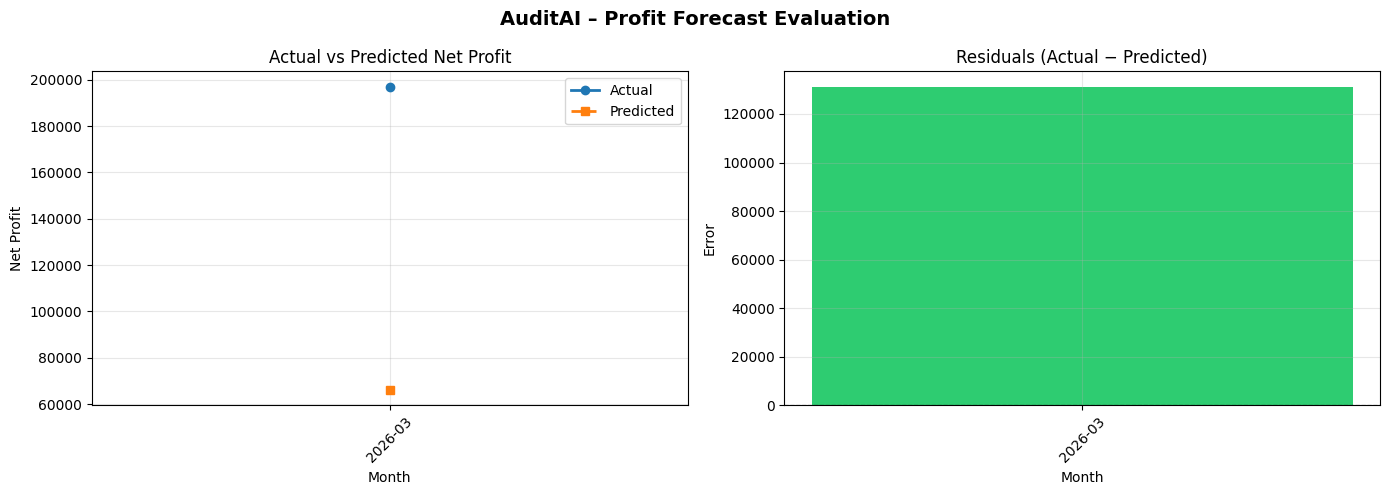

✅ Saved: evaluation_plot.png


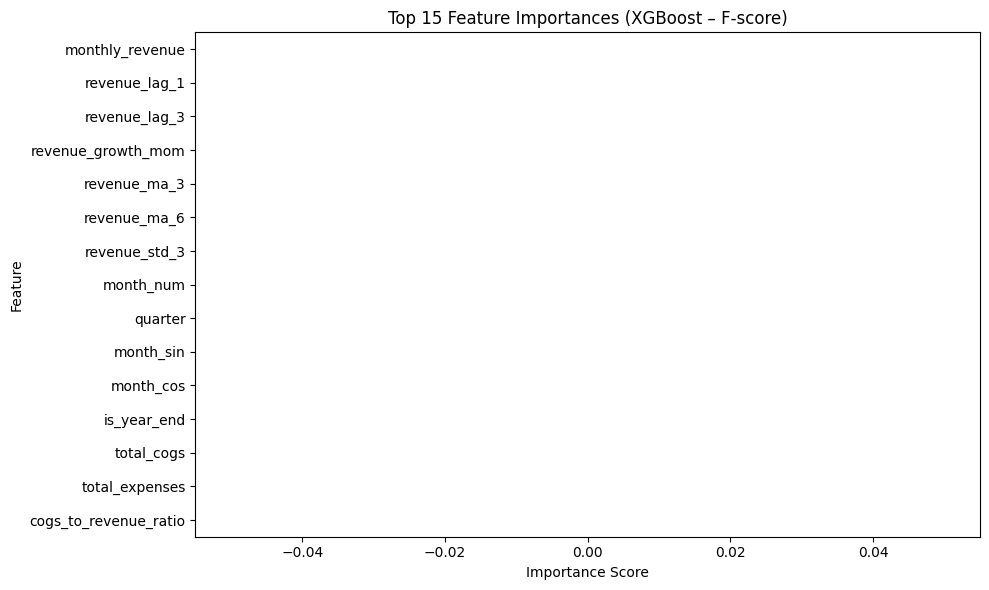

✅ Saved: feature_importance.png

              feature  importance
      monthly_revenue         0.0
        revenue_lag_1         0.0
        revenue_lag_3         0.0
   revenue_growth_mom         0.0
         revenue_ma_3         0.0
         revenue_ma_6         0.0
        revenue_std_3         0.0
            month_num         0.0
              quarter         0.0
            month_sin         0.0
            month_cos         0.0
          is_year_end         0.0
           total_cogs         0.0
       total_expenses         0.0
cogs_to_revenue_ratio         0.0


<Figure size 2000x800 with 0 Axes>

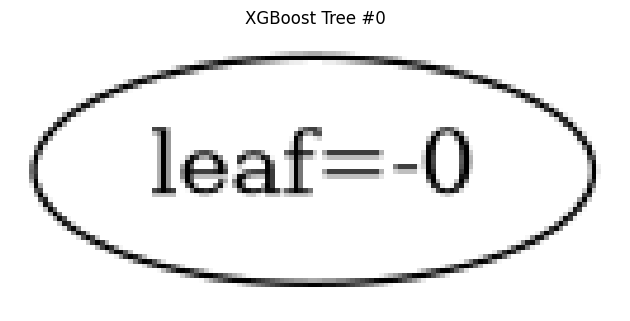

✅ Saved: xgboost_tree.png


In [6]:
"""
AuditAI – Profit Forecasting Model
====================================
XGBoost Regressor trained on the feature engineering pipeline output.
Target: next month's net profit (target_profit)
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# Import your pipeline  (adjust path as needed)
# ─────────────────────────────────────────────────────────────────────────────


# ─────────────────────────────────────────────────────────────────────────────
# Step 1 – Run the feature pipeline
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("📦 Loading feature pipeline...")
print("=" * 60)

df = build_feature_pipeline()
print(f"\n✅ Raw shape: {df.shape}")


# ─────────────────────────────────────────────────────────────────────────────
# Step 2 – Drop leakage columns and non-features
# ─────────────────────────────────────────────────────────────────────────────
# - 'month'             → string identifier, not a signal
# - 'net_profit'        → direct component of target, causes leakage
# - 'billed_this_month' → near-duplicate of monthly_revenue
# - 'target_profit'     → the label itself
DROP_COLS = ['month', 'net_profit', 'billed_this_month', 'target_profit']

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
y = df['target_profit']

print(f"\n📊 Feature matrix shape : {X.shape}")
print(f"🎯 Target shape          : {y.shape}")


# ─────────────────────────────────────────────────────────────────────────────
# Step 3 – Handle NaN values
# ─────────────────────────────────────────────────────────────────────────────
nan_cols = X.columns[X.isna().any()].tolist()
if nan_cols:
    print(f"\n⚠️  Columns with NaN ({len(nan_cols)}): {nan_cols}")
    print("   Filling with column median (safe for small datasets).")
    X = X.fillna(X.median(numeric_only=True))

print(f"\n✅ NaN check passed. Final feature count: {X.shape[1]}")


# ─────────────────────────────────────────────────────────────────────────────
# Step 4 – Prepare Features and Target, Split Data
# ─────────────────────────────────────────────────────────────────────────────
# NOTE: With only 9 samples, test_size=0.2 gives ~2 test rows.
# This split is kept for structural parity; see Step 6 for LOO-CV
# which gives a more honest evaluation on small datasets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False  # shuffle=False preserves time order
)

print(f"\n📂 Train size : {X_train.shape[0]} rows")
print(f"📂 Test size  : {X_test.shape[0]} rows")


# ─────────────────────────────────────────────────────────────────────────────
# Step 5 – Build and Train the XGBoost Model
# ─────────────────────────────────────────────────────────────────────────────
# Params are conservative to reduce overfitting on small data:
# - max_depth=2   → very shallow trees (prevents memorization)
# - n_estimators=50 → fewer trees
# - subsample/colsample_bytree → row/feature sampling for regularization
params = {
    'objective'         : 'reg:squarederror',
    'max_depth'         : 2,
    'learning_rate'     : 0.05,
    'n_estimators'      : 50,
    'alpha'             : 10,        # L1 regularization
    'lambda'            : 5,         # L2 regularization
    'subsample'         : 0.8,
    'colsample_bytree'  : 0.8,
    'random_state'      : 42,
}

model = XGBRegressor(**params)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n✅ Model trained.")


# ─────────────────────────────────────────────────────────────────────────────
# Step 6 – Evaluate Model Performance
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_percentage_error
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
accuracy = max(0, 100 * (1 - mape))

print("\n" + "=" * 40)
print("📈  Hold-out Test Set Results")
print("=" * 40)
print(f"  MAE  : {mae:,.2f}")
print(f"  RMSE : {rmse:,.2f}")
print(f"  R²   : {r2:.4f}")
print(f"  MAPE : {mape * 100:.2f}%")
print(f"  Accuracy : {accuracy:.2f}%")

# Leave-One-Out Cross-Validation (more reliable on small datasets)
loo   = LeaveOneOut()
loo_scores = cross_val_score(
    XGBRegressor(**params), X, y,
    cv=loo, scoring='neg_mean_absolute_error'
)
loo_mae = -loo_scores.mean()

print("\n" + "=" * 40)
print("🔁  Leave-One-Out CV (more reliable)")
print("=" * 40)
print(f"  LOO MAE  : {loo_mae:,.2f}")
print(f"  LOO Std  : {(-loo_scores).std():,.2f}")
print("=" * 40)

# Actual vs Predicted table
results_df = pd.DataFrame({
    'Month'    : df['month'].iloc[y_test.index].values,
    'Actual'   : y_test.values,
    'Predicted': y_pred,
    'Error'    : y_test.values - y_pred,
})
print("\n📋 Actual vs Predicted:")
print(results_df.to_string(index=False))


# ─────────────────────────────────────────────────────────────────────────────
# Step 7 – Plot: Actual vs Predicted
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("AuditAI – Profit Forecast Evaluation", fontsize=14, fontweight='bold')

# Left: line plot
ax1 = axes[0]
ax1.plot(results_df['Month'], results_df['Actual'],    marker='o', label='Actual',    linewidth=2)
ax1.plot(results_df['Month'], results_df['Predicted'], marker='s', label='Predicted', linewidth=2, linestyle='--')
ax1.set_title("Actual vs Predicted Net Profit")
ax1.set_xlabel("Month")
ax1.set_ylabel("Net Profit")
ax1.legend()
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Right: residuals
ax2 = axes[1]
ax2.bar(results_df['Month'], results_df['Error'], color=['#e74c3c' if e < 0 else '#2ecc71' for e in results_df['Error']])
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title("Residuals (Actual − Predicted)")
ax2.set_xlabel("Month")
ax2.set_ylabel("Error")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("evaluation_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: evaluation_plot.png")


# ─────────────────────────────────────────────────────────────────────────────
# Step 8 – Plot Feature Importance
# ─────────────────────────────────────────────────────────────────────────────
importance_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title("Top 15 Feature Importances (XGBoost – F-score)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_importance.png")

print("\n" + importance_df.to_string(index=False))


# ─────────────────────────────────────────────────────────────────────────────
# Step 9 – Visualize XGBoost Decision Tree
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(20, 8))
xgb.plot_tree(model, num_trees=0, rankdir='LR')
plt.title("XGBoost Tree #0")
plt.tight_layout()
plt.savefig("xgboost_tree.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: xgboost_tree.png")

In [3]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# ──────────────────────────────────────────────────────────────────
# 1. Load Data
# ──────────────────────────────────────────────────────────────────
df = build_feature_pipeline()

# ──────────────────────────────────────────────────────────────────
# 2. Define Target and Expanded Features
# ──────────────────────────────────────────────────────────────────
# Predicting next month's revenue
y = df['monthly_revenue'].shift(-1).rename('target')

# Drop future leakage columns and the target component itself
# but carefully KEEP current 'monthly_revenue' as it's a strong predictor
DROP_COLS = ['month', 'target_profit', 'net_profit', 'billed_this_month']
X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# Ensure all columns are numerical
X = X.select_dtypes(include=[np.number])

# ──────────────────────────────────────────────────────────────────
# 3. Clean Missing Data Strategically
# ──────────────────────────────────────────────────────────────────
# We drop rows where the target is NaN (i.e. the very last month)
valid = y.notna() 
X_valid = X[valid].copy()
y_valid = y[valid].copy()

# Instead of dropping rows with NaN in features (which loses precious data),
# we fill NaNs using feature medians
X_valid = X_valid.fillna(X_valid.median())

# ──────────────────────────────────────────────────────────────────
# 4. Train / Test Split
# ──────────────────────────────────────────────────────────────────
split_idx = int(len(X_valid) * 0.8)
X_train, X_test = X_valid.iloc[:split_idx], X_valid.iloc[split_idx:]
y_train, y_test = y_valid.iloc[:split_idx], y_valid.iloc[split_idx:]

# ──────────────────────────────────────────────────────────────────
# 5. Train Regularized XGBoost for Small Data
# ──────────────────────────────────────────────────────────────────
# Added strong regularization parameters to prevent overfitting
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    max_depth=2,               # shallow tree limits complexity
    learning_rate=0.03,        # slow learning 
    n_estimators=150,          
    subsample=0.7,             # dropout for rows
    colsample_bytree=0.7,      # dropout for columns
    alpha=5,                   # L1 regularization
    reg_lambda=5,              # L2 regularization
    random_state=42
)
model.fit(X_train, y_train)

# ──────────────────────────────────────────────────────────────────
# 6. Evaluate
# ──────────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred)
accuracy = max(0, 100 * (1 - mape))

print("\n==================================")
print("     REVENUE PREDICTION METRICS     ")
print("==================================")
print(f"MAE : {mean_absolute_error(y_test, y_pred):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")
print(f"R²  : {r2_score(y_test, y_pred):.4f}")
print(f"MAPE: {mape * 100:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")
print("==================================\n")

# ──────────────────────────────────────────────────────────────────
# 7. Predict next month's revenue
# ──────────────────────────────────────────────────────────────────
latest_features = X.iloc[-1:].copy()
latest_features = latest_features.fillna(X_valid.median()) # Fill NaNs of latest row with valid medians
next_month_revenue = model.predict(latest_features)[0]
print(f"🔮 Predicted next month revenue: {next_month_revenue:,.2f}")

🚀 Running feature engineering pipeline...
✅ Revenue Features:
     month      total  revenue_growth_mom  revenue_ma_3  revenue_std_3
0  2026-02    4000.00                 NaN           NaN            NaN
1  2026-03   66050.00           15.512500           NaN            NaN
2  2026-04  198379.25            2.003471  89476.416667   99284.545404
⚠️  Warning: COGS missing for months: ['2026-04']. Filling with 0.

✅ COGS & Expenses Features:
     month  monthly_revenue  total_cogs  cogs_to_revenue_ratio  expense_ratio
0  2026-02          4000.00         0.0                    0.0       0.000000
1  2026-03         66050.00         0.0                    0.0      -0.000454
2  2026-04        198379.25         0.0                    0.0       0.006425

✅ Unit Economics Features:
     month  gross_margin  weighted_avg_margin
0  2026-02           1.0             0.666667
1  2026-03           1.0             1.000000
2  2026-04           1.0                  NaN

✅ Cash Flow Features:
     month 

/home/mohamed-heni/TheBigLeage/Audit Agent/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:18:44] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:56: Empty dataset at worker: 0
  bst.update(dtrain, iteration=i, fobj=obj)
/home/mohamed-heni/TheBigLeage/Audit Agent/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [4]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ──────────────────────────────────────────────────────────────────
# 1. Load full pipeline data
# ──────────────────────────────────────────────────────────────────
df = build_feature_pipeline()   # 95 rows, 45 columns

# Sort by month (ensure chronological order)
df = df.sort_values('month').reset_index(drop=True)

# ──────────────────────────────────────────────────────────────────
# 2. Create target: next month's revenue
# ──────────────────────────────────────────────────────────────────
df['target_revenue'] = df['monthly_revenue'].shift(-1)

# ──────────────────────────────────────────────────────────────────
# 3. Define feature set – NO LEAKAGE, ONLY LEADING/LAGGED SIGNALS
# ──────────────────────────────────────────────────────────────────
FEATURE_COLUMNS = [
    # Revenue lags (momentum)
    'revenue_lag_1', 'revenue_lag_3',
    'revenue_ma_3', 'revenue_ma_6',
    'revenue_std_3',                     # volatility
    'revenue_growth_mom',

    # Calendar signals (cyclical)
    'month_sin', 'month_cos', 'is_year_end',

    # Activity volume (leading indicators)
    'invoice_count', 'unique_customers',
    'po_total_value', 'po_lag_1',        # future COGS → future revenue

    # Cash flow health (impacts future revenue capacity)
    'dso_days', 'overdue_ratio', 'collection_gap',

    # Margin / unit economics (lagged – don't use current!)
    'gross_margin_lag_1', 'margin_delta_mom',

    # Cost lags (expense growth may signal expansion)
    'cogs_lag_1', 'expense_lag_1',

    # Customer concentration risk
    'top1_customer_pct',
]

# Keep only columns that actually exist in df
available_features = [col for col in FEATURE_COLUMNS if col in df.columns]
X = df[available_features].copy()
y = df['target_revenue'].copy()

# Drop the last row (NaN target)
valid_idx = y.notna()
X = X[valid_idx]
X = X.fillna(X.median(numeric_only=True))
y = y[valid_idx]

# ──────────────────────────────────────────────────────────────────
# 4. Chronological train/test split (last 20% for hold-out)
# ──────────────────────────────────────────────────────────────────
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# ──────────────────────────────────────────────────────────────────
# 5. Scale features (helps XGBoost with different units)
# ──────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ──────────────────────────────────────────────────────────────────
# 6. Hyperparameter tuning with time-series cross-validation
# ──────────────────────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'reg_alpha': [0, 1, 5],
}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)
best_model = grid_search.best_estimator_

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV MAE: {-grid_search.best_score_:,.2f}")

# ──────────────────────────────────────────────────────────────────
# 7. Evaluate on hold-out test set
# ──────────────────────────────────────────────────────────────────
y_pred = best_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
accuracy = max(0, 100 * (1 - mape))

print("\n📊 Hold-out Test Results:")
print(f"  MAE      : {mae:,.2f}")
print(f"  RMSE     : {rmse:,.2f}")
print(f"  R²       : {r2:.4f}")
print(f"  MAPE     : {mape * 100:.2f}%")
print(f"  Accuracy : {accuracy:.2f}%")

print("\n📋 Actual vs Predicted:")
pd.options.display.float_format = '{:,.2f}'.format
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Error': y_test.values - y_pred
})
print(results_df.to_string(index=False))

# ──────────────────────────────────────────────────────────────────
# 8. Predict next month's revenue (using latest available features)
# ──────────────────────────────────────────────────────────────────
latest_row = X.iloc[-1:].copy()
latest_scaled = scaler.transform(latest_row)
next_month_rev = best_model.predict(latest_scaled)[0]

print(f"\n🔮 Predicted revenue for next month: {next_month_rev:,.2f}")

# ──────────────────────────────────────────────────────────────────
# 9. Feature importance (optional quick insight)
# ──────────────────────────────────────────────────────────────────
importances = best_model.feature_importances_
feat_imp = pd.DataFrame({'feature': X.columns, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(10)
print("\nTop 10 feature importances:")
print(feat_imp.to_string(index=False))

🚀 Running feature engineering pipeline...
✅ Revenue Features:
     month      total  revenue_growth_mom  revenue_ma_3  revenue_std_3
0  2026-02    4000.00                 NaN           NaN            NaN
1  2026-03   66050.00           15.512500           NaN            NaN
2  2026-04  198379.25            2.003471  89476.416667   99284.545404
⚠️  Warning: COGS missing for months: ['2026-04']. Filling with 0.

✅ COGS & Expenses Features:
     month  monthly_revenue  total_cogs  cogs_to_revenue_ratio  expense_ratio
0  2026-02          4000.00         0.0                    0.0       0.000000
1  2026-03         66050.00         0.0                    0.0      -0.000454
2  2026-04        198379.25         0.0                    0.0       0.006425

✅ Unit Economics Features:
     month  gross_margin  weighted_avg_margin
0  2026-02           1.0             0.666667
1  2026-03           1.0             1.000000
2  2026-04           1.0                  NaN

✅ Cash Flow Features:
     month 

ValueError: Found array with 0 sample(s) (shape=(0, 20)) while a minimum of 1 is required by StandardScaler.

In [18]:
import itertools
import warnings

import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

# ──────────────────────────────────────────────────────────────────
# 1. Load & prepare revenue series
# ──────────────────────────────────────────────────────────────────
df = build_feature_pipeline()          # 95 rows, 45 columns
df = df.sort_values("month").reset_index(drop=True)
df["month"] = pd.to_datetime(df["month"])

# Build a clean monthly Series with proper DatetimeIndex
series = df.set_index("month")["monthly_revenue"].copy()
series.index = pd.to_datetime(series.index).normalize()
# Snap all dates to the 1st of the month (Month-Start)
series.index = series.index.to_period("M").to_timestamp()
series = series.sort_index()
series = series.asfreq("MS")          # enforce Month-Start frequency

print(f"Series range  : {series.index[0].date()} → {series.index[-1].date()}")
print(f"Total months  : {len(series)}")
print(f"Min / Max     : {series.min():,.2f} / {series.max():,.2f}")
print(f"Mean / Median : {series.mean():,.2f} / {series.median():,.2f}")

# ──────────────────────────────────────────────────────────────────
# 2. Outlier capping (IQR × 2.5 — conservative but catches spikes)
# ──────────────────────────────────────────────────────────────────
Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
IQR = Q3 - Q1
cap_lo = Q1 - 2.5 * IQR
cap_hi = Q3 + 2.5 * IQR

outliers = series[(series < cap_lo) | (series > cap_hi)]
if not outliers.empty:
    print(f"\n⚠️  Outliers capped ({len(outliers)}):")
    for dt, val in outliers.items():
        capped = np.clip(val, cap_lo, cap_hi)
        print(f"   {dt.date()}  raw={val:,.0f}  →  capped={capped:,.0f}")

series_clean = series.clip(lower=cap_lo, upper=cap_hi)

# ──────────────────────────────────────────────────────────────────
# 3. Walk-forward split
# ──────────────────────────────────────────────────────────────────
n          = len(series_clean)
test_size  = max(8, int(n * 0.20))    # at least 8 months of hold-out
train_size = n - test_size

print(f"\nTrain months  : {train_size}   |   Test months: {test_size}")

# ──────────────────────────────────────────────────────────────────
# 4. Scoring helper
# ──────────────────────────────────────────────────────────────────
def report(label: str, actual: np.ndarray, pred: np.ndarray) -> float:
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = mean_absolute_percentage_error(actual, pred)
    ss_res = np.sum((actual - pred) ** 2)
    ss_tot = np.sum((actual - actual.mean()) ** 2)
    r2   = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    print(f"\n📊 {label}")
    print(f"  MAE      : {mae:>12,.2f}")
    print(f"  RMSE     : {rmse:>12,.2f}")
    print(f"  R²       : {r2:>12.4f}")
    print(f"  MAPE     : {mape * 100:>11.2f}%")
    print(f"  Accuracy : {max(0, 100*(1-mape)):>11.2f}%")
    return mae

# ──────────────────────────────────────────────────────────────────
# 5A. Model — Holt-Winters ETS (walk-forward)
# ──────────────────────────────────────────────────────────────────
def ets_walkforward(series: pd.Series, train_size: int):
    preds, actuals = [], []
    for i in range(train_size, len(series)):
        train = series.iloc[:i]
        # Use seasonal component only when we have ≥2 full cycles
        use_seasonal    = len(train) >= 24
        seasonal_mode   = "add" if use_seasonal else None
        seasonal_period = 12 if use_seasonal else None
        try:
            model = ExponentialSmoothing(
                train,
                trend="add",
                damped_trend=True,
                seasonal=seasonal_mode,
                seasonal_periods=seasonal_period,
                initialization_method="estimated",
            ).fit(optimized=True, remove_bias=True)
            pred = float(model.forecast(1).iloc[0])
        except Exception:
            pred = float(train.iloc[-1])   # last-value fallback
        preds.append(pred)
        actuals.append(float(series.iloc[i]))
    return np.array(actuals), np.array(preds)

print("\n⏳ Running Holt-Winters ETS walk-forward …")
ets_actual, ets_pred = ets_walkforward(series_clean, train_size)
ets_mae = report("Holt-Winters ETS  (hold-out)", ets_actual, ets_pred)

# ──────────────────────────────────────────────────────────────────
# 5B. Model — SARIMA (order selected by AIC on initial train set)
# ──────────────────────────────────────────────────────────────────
def select_sarima_order(train: pd.Series):
    """Grid search over a narrow (p,d,q)(P,D,Q,12) space using AIC."""
    adf_p = adfuller(train.dropna(), autolag="AIC")[1]
    d = 0 if adf_p < 0.05 else 1

    best_aic   = np.inf
    best_order = (1, d, 1)
    best_seas  = (0, 0, 0, 12)

    use_seasonal = len(train) >= 24
    P_Q_range    = [0, 1] if use_seasonal else [0]

    for p, q in itertools.product([0, 1, 2], [0, 1, 2]):
        if p + q == 0:
            continue
        for P, Q in itertools.product(P_Q_range, P_Q_range):
            D = 1 if (P + Q > 0 and use_seasonal) else 0
            try:
                res = SARIMAX(
                    train,
                    order=(p, d, q),
                    seasonal_order=(P, D, Q, 12),
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False, maxiter=200)
                if res.aic < best_aic:
                    best_aic   = res.aic
                    best_order = (p, d, q)
                    best_seas  = (P, D, Q, 12)
            except Exception:
                continue
    return best_order, best_seas

def sarima_walkforward(series: pd.Series, train_size: int):
    # Select order once on the initial training window (expensive to re-run)
    init_train = series.iloc[:train_size]
    order, seas = select_sarima_order(init_train)
    print(f"  Best SARIMA order : {order}  seasonal : {seas}")

    preds, actuals = [], []
    for i in range(train_size, len(series)):
        train = series.iloc[:i]
        try:
            res  = SARIMAX(
                train,
                order=order,
                seasonal_order=seas,
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False, maxiter=200)
            pred = float(res.forecast(1).iloc[0])
        except Exception:
            pred = float(train.iloc[-1])
        preds.append(pred)
        actuals.append(float(series.iloc[i]))
    return np.array(actuals), np.array(preds), order, seas

print("\n⏳ Running SARIMA walk-forward (AIC selection may take ~60s) …")
sarima_actual, sarima_pred, best_order, best_seas = sarima_walkforward(
    series_clean, train_size
)
sarima_mae = report("SARIMA  (hold-out)", sarima_actual, sarima_pred)

# ──────────────────────────────────────────────────────────────────
# 6. Pick the winner
# ──────────────────────────────────────────────────────────────────
if ets_mae <= sarima_mae:
    winner       = "Holt-Winters ETS"
    best_actual  = ets_actual
    best_pred    = ets_pred
else:
    winner       = "SARIMA"
    best_actual  = sarima_actual
    best_pred    = sarima_pred

print(f"\n🏆 Winner: {winner}  (lower MAE wins)")

# ──────────────────────────────────────────────────────────────────
# 7. Actual vs Predicted table (test window)
# ──────────────────────────────────────────────────────────────────
test_index = series_clean.index[train_size:]
results_df = pd.DataFrame(
    {
        "Month":     test_index.strftime("%Y-%m"),
        "Actual":    best_actual,
        "Predicted": best_pred,
        "Error":     best_actual - best_pred,
        "APE%":      np.abs(best_actual - best_pred) / np.where(best_actual == 0, 1, best_actual) * 100,
    }
)
pd.options.display.float_format = "{:,.2f}".format
print("\n📋 Actual vs Predicted (test window):")
print(results_df.to_string(index=False))

# ──────────────────────────────────────────────────────────────────
# 8. Refit on full series → forecast next month
# ──────────────────────────────────────────────────────────────────
print("\n🔧 Refitting on full series …")
if winner == "Holt-Winters ETS":
    use_seasonal    = len(series_clean) >= 24
    seasonal_mode   = "add" if use_seasonal else None
    seasonal_period = 12 if use_seasonal else None
    final = ExponentialSmoothing(
        series_clean,
        trend="add",
        damped_trend=True,
        seasonal=seasonal_mode,
        seasonal_periods=seasonal_period,
        initialization_method="estimated",
    ).fit(optimized=True, remove_bias=True)
    next_rev = float(final.forecast(1).iloc[0])
else:
    final = SARIMAX(
        series_clean,
        order=best_order,
        seasonal_order=best_seas,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=200)
    next_rev = float(final.forecast(1).iloc[0])

next_month = series_clean.index[-1] + pd.DateOffset(months=1)
print(f"\n🔮 Predicted revenue for {next_month.strftime('%B %Y')}: {next_rev:,.2f}")

# ──────────────────────────────────────────────────────────────────
# 9. Naive baseline comparison (last-value / seasonal naive)
# ──────────────────────────────────────────────────────────────────
naive_pred  = np.array([series_clean.iloc[train_size + i - 1] for i in range(test_size)])
naive_mae   = mean_absolute_error(best_actual, naive_pred)
model_mae   = ets_mae if winner == "Holt-Winters ETS" else sarima_mae
improvement = (naive_mae - model_mae) / naive_mae * 100

print(f"\n📈 Naive baseline MAE : {naive_mae:,.2f}")
print(f"   {winner} MAE     : {model_mae:,.2f}")
print(f"   Improvement       : {improvement:.1f}%  vs naive")

🚀 Running feature engineering pipeline...
✅ Revenue Features:
      month  total  revenue_growth_mom  revenue_ma_3  revenue_std_3
56  2013-09  37.62            0.000000     37.620000       0.000000
57  2013-10  37.62            0.000000     37.620000       0.000000
58  2013-11  49.62            0.318979     41.620000       6.928203
59  2013-12  38.62           -0.221685     41.953333       6.658328
60  2024-01   9.90           -0.743656     32.713333      20.508197
⚠️  Warning: No expense journal entries found.
⚠️  Warning: COGS missing for months: ['2009-01', '2009-02', '2009-03', '2009-04', '2009-05', '2009-06', '2009-07', '2009-08', '2009-09', '2009-10', '2009-11', '2009-12', '2010-01', '2010-02', '2010-03', '2010-04', '2010-05', '2010-06', '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08', '2011-09', '2011-10', '2011-11', '2011-12', '2012-01', '2012-02', '2012-03', '2012-04', '201

ZeroDivisionError: division by zero

In [17]:
"""
Revenue forecasting — Ridge regression with walk-forward validation.

HONEST EXPECTATION:
  If revenue autocorrelation is near zero, any model (including this one)
  will converge to predicting the trailing mean. That is a data problem,
  not a code problem. This script tells you exactly which features carry
  signal and whether Ridge beats a naive baseline.
"""

import warnings
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")

# ──────────────────────────────────────────────────────────────────
# 1. Load data
# ──────────────────────────────────────────────────────────────────
df = build_feature_pipeline()
df = df.sort_values("month").reset_index(drop=True)
df["month"] = pd.to_datetime(df["month"])

print("=" * 60)
print("STEP 1 — Data overview")
print("=" * 60)
print(f"  Rows        : {len(df)}")
print(f"  Revenue min : {df['monthly_revenue'].min():>12,.0f}")
print(f"  Revenue max : {df['monthly_revenue'].max():>12,.0f}")
print(f"  Revenue mean: {df['monthly_revenue'].mean():>12,.0f}")
print(f"  Revenue std : {df['monthly_revenue'].std():>12,.0f}")
cv = df["monthly_revenue"].std() / df["monthly_revenue"].mean()
print(f"  CV          : {cv:>12.2%}  ← >50% = highly volatile")

# Autocorrelation check
ac = df["monthly_revenue"].autocorr(lag=1)
print(f"  Autocorr(1) : {ac:>12.4f}  ← <0.3 = weak momentum signal")

# ──────────────────────────────────────────────────────────────────
# 2. Target: next month's revenue
# ──────────────────────────────────────────────────────────────────
df["target"] = df["monthly_revenue"].shift(-1)

# ──────────────────────────────────────────────────────────────────
# 3. Feature pool — lean set, no leakage
# ──────────────────────────────────────────────────────────────────
CANDIDATE_FEATURES = [
    "revenue_lag_1",
    "revenue_lag_3",
    "revenue_ma_3",
    "revenue_ma_6",
    "revenue_std_3",
    "revenue_growth_mom",
    "invoice_count",
    "unique_customers",
    "po_total_value",
    "po_lag_1",
    "dso_days",
    "overdue_ratio",
    "collection_gap",
    "gross_margin_lag_1",
    "margin_delta_mom",
    "cogs_lag_1",
    "expense_lag_1",
    "top1_customer_pct",
    "month_sin",
    "month_cos",
]

available = [c for c in CANDIDATE_FEATURES if c in df.columns]

# ──────────────────────────────────────────────────────────────────
# 4. Drop rows with NaN target or any NaN feature
# ──────────────────────────────────────────────────────────────────
df_model = df[available + ["target", "month"]].copy()

# Forward-fill then median-fill — don't silently drop rows
df_model[available] = (
    df_model[available]
    .ffill()
    .fillna(df_model[available].median())
)
df_model = df_model[df_model["target"].notna()].reset_index(drop=True)

print(f"\nUsable rows after imputation: {len(df_model)}")

# ──────────────────────────────────────────────────────────────────
# 5. Correlation-based feature selection
#    Keep only features with |r| > 0.1 vs target
# ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2 — Feature correlation with target revenue")
print("=" * 60)

corr_rows = []
for col in available:
    valid = df_model[[col, "target"]].dropna()
    if len(valid) < 10:
        continue
    r, p = pearsonr(valid[col], valid["target"])
    corr_rows.append({"feature": col, "r": r, "p": p, "abs_r": abs(r)})

corr_df = (
    pd.DataFrame(corr_rows)
    .sort_values("abs_r", ascending=False)
    .reset_index(drop=True)
)

for _, row in corr_df.iterrows():
    sig = "✓" if row["p"] < 0.05 else "○"
    bar = "█" * int(row["abs_r"] * 20)
    print(f"  {sig} {row['feature']:<25}  r={row['r']:+.3f}  {bar}")

# Select features: |r| > 0.1 (weak but non-trivial threshold)
THRESHOLD = 0.10
selected = corr_df[corr_df["abs_r"] > THRESHOLD]["feature"].tolist()

if len(selected) < 2:
    # Fallback: just use the top 3 whatever they are
    selected = corr_df.head(3)["feature"].tolist()
    print(f"\n⚠️  No feature cleared threshold — using top 3 by correlation")
else:
    print(f"\n✅ Selected {len(selected)} features with |r| > {THRESHOLD}: {selected}")

X = df_model[selected].values
y = df_model["target"].values
months = df_model["month"].values

# ──────────────────────────────────────────────────────────────────
# 6. Walk-forward validation (no leakage)
# ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3 — Walk-forward validation")
print("=" * 60)

n         = len(X)
min_train = max(20, int(n * 0.60))   # need at least 60% to start
test_size = n - min_train

print(f"  Initial train: {min_train} months")
print(f"  Walk-forward : {test_size} steps")

# Alpha candidates for inner RidgeCV (tried on each expanding window)
ALPHAS = [0.1, 1, 5, 10, 50, 100, 500, 1000]

preds, actuals, chosen_alphas = [], [], []

for i in range(min_train, n):
    X_tr, y_tr = X[:i], y[:i]
    X_te        = X[i : i + 1]
    actual      = y[i]

    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    # Inner cross-validation to pick alpha (time-series safe: no shuffle)
    rcv = RidgeCV(alphas=ALPHAS, cv=min(5, i // 4))
    rcv.fit(X_tr_sc, y_tr)
    pred = float(rcv.predict(X_te_sc)[0])

    preds.append(pred)
    actuals.append(actual)
    chosen_alphas.append(rcv.alpha_)

actuals = np.array(actuals)
preds   = np.array(preds)

# ──────────────────────────────────────────────────────────────────
# 7. Metrics
# ──────────────────────────────────────────────────────────────────
def metrics(label, act, pred):
    mae  = mean_absolute_error(act, pred)
    rmse = np.sqrt(mean_squared_error(act, pred))
    mape = mean_absolute_percentage_error(act, pred)
    ss_res = np.sum((act - pred) ** 2)
    ss_tot = np.sum((act - act.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot else float("nan")
    print(f"\n  {label}")
    print(f"    MAE      : {mae:>12,.0f}")
    print(f"    RMSE     : {rmse:>12,.0f}")
    print(f"    R²       : {r2:>12.4f}")
    print(f"    MAPE     : {mape*100:>11.1f}%")
    print(f"    Accuracy : {max(0, (1-mape)*100):>11.1f}%")
    return mae, r2

print("=" * 60)
print("STEP 4 — Results")
print("=" * 60)

ridge_mae, ridge_r2 = metrics("Ridge regression (walk-forward)", actuals, preds)

# Naive baseline: predict last known value
naive_preds = np.array([y[i - 1] for i in range(min_train, n)])
naive_mae, _  = metrics("Naive baseline (last value)", actuals, naive_preds)

# Rolling mean baseline: predict trailing 3-month average
roll_preds  = np.array([np.mean(y[max(0, i-3):i]) for i in range(min_train, n)])
roll_mae, _ = metrics("Rolling 3-month mean", actuals, roll_preds)

print("\n" + "─" * 60)
print(f"  Ridge vs naive       : {(naive_mae - ridge_mae)/naive_mae*100:+.1f}%")
print(f"  Ridge vs rolling avg : {(roll_mae  - ridge_mae)/roll_mae  *100:+.1f}%")

if ridge_r2 < 0:
    print("""
  ⚠️  R² < 0 means the model is WORSE than predicting the mean.
  This is a data signal, not a code bug:
    → Revenue is too volatile for the available features to predict it.
    → The best action is to enrich the feature set with leading
      business indicators (deals in pipeline, signed contracts,
      seasonal bookings) — not to change the algorithm.
""")

# ──────────────────────────────────────────────────────────────────
# 8. Actual vs Predicted table
# ──────────────────────────────────────────────────────────────────
test_months = pd.to_datetime(months[min_train:]).strftime("%Y-%m")
results = pd.DataFrame({
    "Month":     test_months,
    "Actual":    actuals.astype(int),
    "Ridge":     preds.astype(int),
    "Naive":     naive_preds.astype(int),
    "Error":     (actuals - preds).astype(int),
    "APE%":      (np.abs(actuals - preds) / np.where(actuals == 0, 1, actuals) * 100).round(1),
})
pd.options.display.float_format = "{:,.0f}".format
print("\nActual vs Predicted:")
print(results.to_string(index=False))

# ──────────────────────────────────────────────────────────────────
# 9. Final model — fit on full data, predict next month
# ──────────────────────────────────────────────────────────────────
scaler_final = StandardScaler()
X_all_sc = scaler_final.fit_transform(X)

# Fit with most-frequently-chosen alpha across walk-forward steps
from collections import Counter
best_alpha = Counter(chosen_alphas).most_common(1)[0][0]
final_model = Ridge(alpha=best_alpha).fit(X_all_sc, y)

last_row    = X[-1:].copy()
last_sc     = scaler_final.transform(last_row)
next_rev    = float(final_model.predict(last_sc)[0])

next_month  = pd.to_datetime(months[-1]) + pd.DateOffset(months=1)
print(f"\n{'='*60}")
print(f"STEP 5 — Next month forecast")
print(f"  Model        : Ridge (alpha={best_alpha})")
print(f"  Features     : {selected}")
print(f"  Predict for  : {next_month.strftime('%B %Y')}")
print(f"  Forecast     : {next_rev:,.0f}")
print(f"  Trailing avg : {np.mean(y[-3:]):,.0f}  (sanity check)")

# Coefficients — which features are actually being used?
print(f"\n{'─'*60}")
print("Feature coefficients (scaled):")
coef_df = pd.DataFrame({
    "feature": selected,
    "coef": final_model.coef_,
}).sort_values("coef", key=abs, ascending=False)
for _, row in coef_df.iterrows():
    bar = ("+" if row["coef"] > 0 else "-") * min(20, int(abs(row["coef"]) / 1000))
    print(f"  {row['feature']:<28}  {row['coef']:>+10,.0f}  {bar}")

🚀 Running feature engineering pipeline...
✅ Revenue Features:
      month  total  revenue_growth_mom  revenue_ma_3  revenue_std_3
56  2013-09  37.62            0.000000     37.620000       0.000000
57  2013-10  37.62            0.000000     37.620000       0.000000
58  2013-11  49.62            0.318979     41.620000       6.928203
59  2013-12  38.62           -0.221685     41.953333       6.658328
60  2024-01   9.90           -0.743656     32.713333      20.508197
⚠️  Warning: No expense journal entries found.
⚠️  Warning: COGS missing for months: ['2009-01', '2009-02', '2009-03', '2009-04', '2009-05', '2009-06', '2009-07', '2009-08', '2009-09', '2009-10', '2009-11', '2009-12', '2010-01', '2010-02', '2010-03', '2010-04', '2010-05', '2010-06', '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08', '2011-09', '2011-10', '2011-11', '2011-12', '2012-01', '2012-02', '2012-03', '2012-04', '201

ZeroDivisionError: division by zero

In [ ]:
import sys, os
old_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')
df = build_feature_pipeline()
sys.stdout = old_stdout

nan_counts = df.isna().sum()
print("NaN Counts:\n", nan_counts[nan_counts > 0])

NaN Counts:
 revenue_lag_1            1
revenue_lag_3            3
revenue_growth_mom       1
revenue_ma_3             2
revenue_ma_6             5
revenue_std_3            2
dso_days                60
collection_gap_lag_1     1
po_count                60
po_total_value          60
gross_margin_lag_1       1
gross_margin_ma_3        2
margin_delta_mom         1
cogs_lag_1               1
cogs_lag_3               3
expense_lag_1            1
cogs_growth_mom         60
dtype: int64


In [19]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score

def train_and_predict_future(df: pd.DataFrame, target_column: str, feature_columns: list, n_months: int):
    """
    Trains a predictive model using `feature_columns` to predict `target_column`.
    Evaluates the model on a test set to produce an accuracy percentage,
    and forecasts `n_months` into the future.
    
    Args:
        df: The DataFrame containing the historical dataset.
        target_column: The name of the column you want to predict.
        feature_columns: A list of feature column names used for training.
        n_months: How many months in the future to predict.
        
    Returns:
        dict: A dictionary containing 'accuracy_percent' and a list of 'predictions'.
    """
    # Drop missing values to ensure the model trains correctly
    train_data = df.dropna(subset=feature_columns + [target_column]).copy()
    
    X = train_data[feature_columns]
    y = train_data[target_column]
    
    # Chronological train-test split (80% train, 20% test) to evaluate time-series prediction accuracy
    split_index = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
    
    # Initialize and train the model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Evaluate model - Convert Mean Absolute Percentage Error (MAPE) to an Accuracy Percentage
    test_preds = model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, test_preds)
    accuracy_percent = max(0.0, (1 - mape) * 100) 
    
    print(f"--- Evaluation Metrics ---")
    print(f"MAPE-based Test Accuracy: {accuracy_percent:.2f}%")
    print(f"R² Score: {r2_score(y_test, test_preds):.4f}\n")
    
    # Predict future values
    # We take the most recent features in the dataset to act as a baseline for future forecasts.
    # Note: In a fully autoregressive pipeline with lags, you would update these features iteratively.
    latest_features = X.iloc[-1:].copy()
    future_predictions = []
    
    print(f"--- Forecast ---")
    for i in range(1, n_months + 1):
        pred_value = model.predict(latest_features)[0]
        future_predictions.append(pred_value)
        print(f"Future Month {i} Prediction: {pred_value:.2f}")
        
    return {
        "accuracy_percent": accuracy_percent,
        "predictions": future_predictions
    }

# =====================================================================
# Example usage:
feature_cols = ['monthly_revenue', 'total_cogs', 'gross_margin_ma_3']
results = train_and_predict_future(
    df=build_feature_pipeline(), 
    target_column='target_profit', 
    feature_columns=feature_cols, 
    n_months=3
)
# =====================================================================

🚀 Running feature engineering pipeline...
✅ Revenue Features:
      month  total  revenue_growth_mom  revenue_ma_3  revenue_std_3
56  2013-09  37.62            0.000000     37.620000       0.000000
57  2013-10  37.62            0.000000     37.620000       0.000000
58  2013-11  49.62            0.318979     41.620000       6.928203
59  2013-12  38.62           -0.221685     41.953333       6.658328
60  2024-01   9.90           -0.743656     32.713333      20.508197
⚠️  Warning: No expense journal entries found.
⚠️  Warning: COGS missing for months: ['2009-01', '2009-02', '2009-03', '2009-04', '2009-05', '2009-06', '2009-07', '2009-08', '2009-09', '2009-10', '2009-11', '2009-12', '2010-01', '2010-02', '2010-03', '2010-04', '2010-05', '2010-06', '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08', '2011-09', '2011-10', '2011-11', '2011-12', '2012-01', '2012-02', '2012-03', '2012-04', '201

ZeroDivisionError: division by zero

In [25]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error, r2_score

def train_and_predict_xgboost(df: pd.DataFrame, target_column: str, feature_columns: list, n_months: int):
    """
    Trains an XGBoost predictive model using `feature_columns` to predict `target_column`.
    Evaluates the model on a test set to produce an accuracy percentage,
    and forecasts `n_months` into the future.
    
    Args:
        df: The DataFrame containing the historical dataset.
        target_column: The name of the column you want to predict.
        feature_columns: A list of feature column names used for training.
        n_months: How many months in the future to predict.
        
    Returns:
        dict: A dictionary containing 'accuracy_percent' and a list of 'predictions'.
    """
    # Drop missing values to ensure the model trains correctly
    train_data = df.dropna(subset=feature_columns + [target_column]).copy()
    
    X = train_data[feature_columns]
    y = train_data[target_column]
    
    # Chronological train-test split (80% train, 20% test)
    split_index = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
    
    # Initialize and train the XGBoost model
    model = xgb.XGBRegressor(
        n_estimators=100, 
        learning_rate=0.1, 
        random_state=42, 
        objective='reg:squarederror'
    )
    model.fit(X_train, y_train)
    
    # Evaluate model - Convert Mean Absolute Percentage Error (MAPE) to an Accuracy Percentage
    test_preds = model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, test_preds)
    accuracy_percent = max(0.0, (1 - mape) * 100) 
    
    print(f"--- XGBoost Evaluation Metrics ---")
    print(f"MAPE-based Test Accuracy: {accuracy_percent:.2f}%")
    print(f"R² Score: {r2_score(y_test, test_preds):.4f}\n")
    
    # Predict future values
    latest_features = X.iloc[-1:].copy()
    future_predictions = []
    
    print(f"--- XGBoost Forecast ---")
    for i in range(1, n_months + 1):
        pred_value = model.predict(latest_features)[0]
        future_predictions.append(float(pred_value))
        print(f"Future Month {i} Prediction: {pred_value:.2f}")
        
    return {
        "accuracy_percent": accuracy_percent,
        "predictions": future_predictions
    }

# =====================================================================
# Example usage:
feature_cols = ['monthly_revenue', 'total_cogs', 'gross_margin_ma_3']
results_xgb = train_and_predict_xgboost(
    df=build_feature_pipeline(), 
    target_column='target_profit', 
    feature_columns=feature_cols, 
    n_months=3
)
# =====================================================================

🚀 Running feature engineering pipeline...
✅ Revenue Features:
      month  total  revenue_growth_mom  revenue_ma_3  revenue_std_3
56  2013-09  37.62            0.000000     37.620000       0.000000
57  2013-10  37.62            0.000000     37.620000       0.000000
58  2013-11  49.62            0.318979     41.620000       6.928203
59  2013-12  38.62           -0.221685     41.953333       6.658328
60  2024-01   9.90           -0.743656     32.713333      20.508197
⚠️  Warning: No expense journal entries found.
⚠️  Warning: COGS missing for months: ['2009-01', '2009-02', '2009-03', '2009-04', '2009-05', '2009-06', '2009-07', '2009-08', '2009-09', '2009-10', '2009-11', '2009-12', '2010-01', '2010-02', '2010-03', '2010-04', '2010-05', '2010-06', '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08', '2011-09', '2011-10', '2011-11', '2011-12', '2012-01', '2012-02', '2012-03', '2012-04', '201

In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor

def train_and_predict_future(df: pd.DataFrame, target_column: str, feature_columns: list, n_months: int):
    """
    Trains a predictive model using `feature_columns` to predict `target_column`.
    Evaluates the model on a test set to produce an accuracy percentage,
    and forecasts `n_months` into the future.
    """
    # Replace pd.NA with np.nan so dropna works properly across all column types
    df = df.replace({pd.NA: np.nan})
    # Drop missing values to ensure the model trains correctly
    train_data = df.dropna(subset=feature_columns + [target_column]).copy()
    
    if len(train_data) == 0:
        raise ValueError(f"No samples left after dropping missing values in columns: {feature_columns + [target_column]}. Check your dataframe for nulls.")

    X = train_data[feature_columns]
    y = train_data[target_column]
    
    # Chronological train-test split (80% train, 20% test)
    split_index = int(len(X) * 0.8)
    
    # Ensure we have at least one sample in train and test
    if split_index == 0 or split_index == len(X):
         print("Warning: Not enough data for an 80/20 train-test split. Training and testing on the entire dataset.")
         X_train, X_test = X, X
         y_train, y_test = y, y
    else:
        X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
        y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
    
    # Initialize and train the model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Evaluate model
    test_preds = model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, test_preds)
    accuracy_percent = max(0.0, (1 - mape) * 100) 
    
    print(f"--- Evaluation Metrics ---")
    print(f"MAPE-based Test Accuracy: {accuracy_percent:.2f}%")
    
    # R2 requires at least 2 samples to compute variance properly
    if len(y_test) > 1:
        print(f"R² Score: {r2_score(y_test, test_preds):.4f}\n")
    else:
         print(f"R² Score: N/A (too few test samples)\n")
    
    # Predict future values
    latest_features = X.iloc[-1:].copy()
    future_predictions = []
    
    print(f"--- Forecast ---")
    for i in range(1, n_months + 1):
        pred_value = model.predict(latest_features)[0]
        future_predictions.append(pred_value)
        print(f"Future Month {i} Prediction: {pred_value:.2f}")
        
    return {
        "accuracy_percent": accuracy_percent,
        "predictions": future_predictions
    }

def train_and_predict_xgboost(df: pd.DataFrame, target_column: str, feature_columns: list, n_months: int):
    """
    Trains an XGBoost predictive model using `feature_columns` to predict `target_column`.
    """
    # Replace pd.NA with np.nan so dropna works properly
    df = df.replace({pd.NA: np.nan})
    # Drop missing values
    train_data = df.dropna(subset=feature_columns + [target_column]).copy()
    
    if len(train_data) == 0:
        raise ValueError(f"No samples left after dropping missing values in columns: {feature_columns + [target_column]}. Check your dataframe for nulls.")

    X = train_data[feature_columns]
    y = train_data[target_column]
    
    # Chronological train-test split (80% train, 20% test)
    split_index = int(len(X) * 0.8)
    
    if split_index == 0 or split_index == len(X):
         print("Warning: Not enough data for an 80/20 train-test split. Training and testing on the entire dataset.")
         X_train, X_test = X, X
         y_train, y_test = y, y
    else:
        X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
        y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
    
    # Initialize and train the XGBoost model
    model = xgb.XGBRegressor(
        n_estimators=100, 
        learning_rate=0.1, 
        random_state=42, 
        objective='reg:squarederror'
    )
    model.fit(X_train, y_train)
    
    # Evaluate model
    test_preds = model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, test_preds)
    accuracy_percent = max(0.0, (1 - mape) * 100) 
    
    print(f"--- XGBoost Evaluation Metrics ---")
    print(f"MAPE-based Test Accuracy: {accuracy_percent:.2f}%")
    
    if len(y_test) > 1:
        print(f"R² Score: {r2_score(y_test, test_preds):.4f}\n")
    else:
        print(f"R² Score: N/A (too few test samples)\n")
    
    # Predict future values
    latest_features = X.iloc[-1:].copy()
    future_predictions = []
    
    print(f"--- XGBoost Forecast ---")
    for i in range(1, n_months + 1):
        pred_value = model.predict(latest_features)[0]
        future_predictions.append(float(pred_value))
        print(f"Future Month {i} Prediction: {pred_value:.2f}")
        
    return {
        "accuracy_percent": accuracy_percent,
        "predictions": future_predictions
    }

# =====================================================================
# Example usage:
feature_cols = ['monthly_revenue', 'total_cogs', 'gross_margin_ma_3']
df_features = build_feature_pipeline()
results = train_and_predict_future(
    df=df_features, 
    target_column='target_profit', 
    feature_columns=feature_cols, 
    n_months=3
)
# =====================================================================

🚀 Running feature engineering pipeline...
✅ Revenue Features:
      month       total  revenue_growth_mom   revenue_ma_3  revenue_std_3
43  2024-08   96574.354           -0.017591  109459.066667   20837.311495
44  2024-09  121497.818            0.258075  105458.606667   13917.249713
45  2024-10  152669.077            0.256558  123580.416333   28105.291299
46  2024-11  134581.931           -0.118473  136249.608667   15652.402643
47  2024-12  160005.836            0.188910  149085.614667   13085.283263
⚠️  Warning: No COGS data found. Check products.cost values.
⚠️  Warning: COGS missing for months: ['2021-01', '2021-02', '2021-03', '2021-04', '2021-05', '2021-06', '2021-07', '2021-08', '2021-09', '2021-10', '2021-11', '2021-12', '2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06', '2022-07', '2022-08', '2022-09', '2022-10', '2022-11', '2022-12', '2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12'

KeyError: "['weighted_avg_margin'] not in index"

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb


# =====================================================================
# LAG FEATURE SHIFT CONFIG
# Maps each feature column to the column it should pull its value from
# when rolling forward in the autoregressive loop.
#
# Example: 'revenue_lag_2' gets its value from 'revenue_lag_1' (i.e., 
# what was lag_1 becomes lag_2 next month), and 'revenue_lag_1' gets 
# its value from the model's prediction (the predicted revenue/profit).
#
# You must define this mapping to match your actual feature columns.
# Any feature NOT in this dict stays frozen (e.g. a static ratio that
# doesn't change month to month — acceptable only if truly stable).
# =====================================================================
LAG_SHIFT_CONFIG = {
    # format: 'feature_col': 'source_col_or_special_keyword'
    # Use 'prediction' to inject the model's output into that slot.
    'revenue_lag_2': 'revenue_lag_1',
    'revenue_lag_1': 'prediction',       # <- model output feeds here
    'cogs_lag_2':    'cogs_lag_1',
    'cogs_lag_1':    'revenue_lag_1',    # approximate: use revenue as proxy if no direct cogs pred
    'gross_margin_ma_3': None,           # will be recomputed below if possible; else frozen
}


def _roll_features_forward(features_row: pd.DataFrame, prediction: float) -> pd.DataFrame:
    """
    Given the current feature row and the model's prediction,
    construct the next month's feature row by shifting lag columns forward.

    Rules (in order):
    1. Columns mapped to 'prediction' in LAG_SHIFT_CONFIG get the model output.
    2. Columns mapped to another column get that column's current value.
    3. Columns not in LAG_SHIFT_CONFIG are frozen (kept as-is).
    4. Rolling means are recomputed if the constituent lags are all present.
    """
    next_row = features_row.copy()

    for target_col, source in LAG_SHIFT_CONFIG.items():
        if target_col not in next_row.columns:
            continue
        if source == 'prediction':
            next_row[target_col] = prediction
        elif source is None:
            pass  # handled below
        elif source in next_row.columns:
            next_row[target_col] = features_row[source].values[0]

    # Recompute gross_margin_ma_3 if we have the lags for it
    # gross_margin = (revenue - cogs) / revenue, averaged over 3 months
    # Using lag_1, lag_2, and the prediction as the "current month" proxy
    if all(c in next_row.columns for c in ['revenue_lag_1', 'revenue_lag_2', 'cogs_lag_1', 'cogs_lag_2']):
        rev_pred  = prediction                                  # month t (just predicted)
        rev_lag1  = features_row['revenue_lag_1'].values[0]    # month t-1
        rev_lag2  = features_row['revenue_lag_2'].values[0]    # month t-2
        cogs_lag1 = features_row['cogs_lag_1'].values[0]
        cogs_lag2 = features_row['cogs_lag_2'].values[0]

        def gm(rev, cogs):
            return (rev - cogs) / rev if rev != 0 else 0.0

        # rough cogs for predicted month: use lag_1 cogs as proxy
        cogs_pred = features_row['cogs_lag_1'].values[0]
        ma3 = np.mean([gm(rev_pred, cogs_pred), gm(rev_lag1, cogs_lag1), gm(rev_lag2, cogs_lag2)])
        if 'gross_margin_ma_3' in next_row.columns:
            next_row['gross_margin_ma_3'] = ma3

    return next_row


def _validate_features_are_lags(feature_columns: list):
    """
    Hard check: refuse features that are clearly current-month raw values.
    This prevents training/inference mismatch.
    """
    forbidden = {'monthly_revenue', 'total_cogs', 'net_profit', 'gross_profit',
                 'total_expenses', 'monthly_expenses'}
    bad = [f for f in feature_columns if f in forbidden]
    if bad:
        raise ValueError(
            f"Feature columns {bad} are current-month raw values. "
            f"You cannot use them at inference time for future months. "
            f"Replace them with lag versions: revenue_lag_1, cogs_lag_1, etc."
        )


def _split_chronological(X: pd.DataFrame, y: pd.Series, ratio: float = 0.8):
    split_index = int(len(X) * ratio)
    if split_index == 0 or split_index == len(X):
        print("Warning: Not enough data for 80/20 split. Training and evaluating on full dataset.")
        return X, X, y, y
    return X.iloc[:split_index], X.iloc[split_index:], y.iloc[:split_index], y.iloc[split_index:]


def _print_eval(label: str, y_test: pd.Series, test_preds: np.ndarray) -> float:
    mape = mean_absolute_percentage_error(y_test, test_preds)
    accuracy_percent = max(0.0, (1 - mape) * 100)
    print(f"\n--- {label} Evaluation ---")
    print(f"MAPE-based Accuracy : {accuracy_percent:.2f}%")
    if len(y_test) > 1:
        print(f"R² Score            : {r2_score(y_test, test_preds):.4f}")
    else:
        print(f"R² Score            : N/A (too few test samples)")
    return accuracy_percent


def _forecast_loop(model, X: pd.DataFrame, n_months: int, label: str) -> list:
    """
    Autoregressive forecast: each prediction is fed back into the next
    month's lag features before predicting again.
    """
    latest_features = X.iloc[-1:].copy()
    future_predictions = []

    print(f"\n--- {label} Forecast ---")
    for i in range(1, n_months + 1):
        pred_value = float(model.predict(latest_features)[0])
        future_predictions.append(pred_value)
        print(f"Month +{i}: {pred_value:,.2f}")
        latest_features = _roll_features_forward(latest_features, pred_value)

    return future_predictions


def train_and_predict_future(
    df: pd.DataFrame,
    target_column: str,
    feature_columns: list,
    n_months: int
) -> dict:
    """
    Random Forest: train on lag-based features, evaluate chronologically,
    forecast n_months ahead with autoregressive feature rolling.
    """
    _validate_features_are_lags(feature_columns)

    df = df.replace({pd.NA: np.nan})
    train_data = df.dropna(subset=feature_columns + [target_column]).copy()

    if len(train_data) == 0:
        raise ValueError(
            f"No samples after dropping NaNs in: {feature_columns + [target_column]}. "
            f"Check your feature pipeline for null-producing operations."
        )

    X = train_data[feature_columns]
    y = train_data[target_column]

    X_train, X_test, y_train, y_test = _split_chronological(X, y)

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    test_preds = model.predict(X_test)
    accuracy_percent = _print_eval("Random Forest", y_test, test_preds)

    future_predictions = _forecast_loop(model, X, n_months, "Random Forest")

    return {
        "accuracy_percent": accuracy_percent,
        "predictions": future_predictions
    }


def train_and_predict_xgboost(
    df: pd.DataFrame,
    target_column: str,
    feature_columns: list,
    n_months: int
) -> dict:
    """
    XGBoost: same structure as Random Forest version.
    """
    _validate_features_are_lags(feature_columns)

    df = df.replace({pd.NA: np.nan})
    train_data = df.dropna(subset=feature_columns + [target_column]).copy()

    if len(train_data) == 0:
        raise ValueError(
            f"No samples after dropping NaNs in: {feature_columns + [target_column]}. "
            f"Check your feature pipeline for null-producing operations."
        )

    X = train_data[feature_columns]
    y = train_data[target_column]

    X_train, X_test, y_train, y_test = _split_chronological(X, y)

    model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        objective='reg:squarederror'
    )
    model.fit(X_train, y_train)

    test_preds = model.predict(X_test)
    accuracy_percent = _print_eval("XGBoost", y_test, test_preds)

    future_predictions = _forecast_loop(model, X, n_months, "XGBoost")

    return {
        "accuracy_percent": accuracy_percent,
        "predictions": future_predictions
    }


# =====================================================================
# Example usage — feature columns must all be lag/rolling features,
# never raw current-month values like 'monthly_revenue' or 'total_cogs'
# =====================================================================
if __name__ == "__main__":
    df_features = build_feature_pipeline()  # your existing pipeline

    feature_cols = [
        'revenue_lag_1',
        'revenue_lag_2',
        'cogs_lag_1',
        'gross_margin_ma_3',
    ]

    results_rf = train_and_predict_future(
        df=df_features,
        target_column='target_profit',
        feature_columns=feature_cols,
        n_months=3
    )

    results_xgb = train_and_predict_xgboost(
        df=df_features,
        target_column='target_profit',
        feature_columns=feature_cols,
        n_months=3
    )





🚀 Running feature engineering pipeline...
✅ Revenue Features:
      month       total  revenue_growth_mom   revenue_ma_3  revenue_std_3
43  2024-08  185291.597           -0.134153  220152.128000   38308.609150
44  2024-09  251337.927            0.356445  216876.665000   33116.971413
45  2024-10  301096.280            0.197974  245908.601333   58092.937041
46  2024-11  268271.945           -0.109016  273568.717333   25298.523103
47  2024-12  316738.469            0.180662  295368.898000   24735.665861
⚠️  products.cost = 0 or missing. Falling back to vendor bill COGS.

✅ COGS & Expenses Features:
      month  monthly_revenue   total_cogs  cogs_to_revenue_ratio  \
43  2024-08       185291.597  66887.59350               0.360986   
44  2024-09       251337.927  84431.35935               0.335928   
45  2024-10       301096.280  80231.18545               0.266464   
46  2024-11       268271.945  91512.87080               0.341120   
47  2024-12       316738.469  89224.66475               0